# Student Mental Health Burnout Prediction System

# Problem Statement

The increasing academic pressure, competitive environments, lifestyle imbalance, and mental health challenges among students have led to a rise in burnout levels. Student burnout can negatively affect academic performance, emotional well-being, and productivity.

This project aims to analyze various student-related factors such as academic workload, mental health indicators, and lifestyle habits to predict burnout levels using machine learning techniques. Early prediction of burnout can help institutions and students identify risks and take preventive measures.

---





## Objectives

- To analyze factors contributing to student mental health burnout.
- To perform exploratory data analysis on student behavioral and academic data.
- To preprocess and prepare the dataset for machine learning.
- To build a machine learning model for burnout prediction.
- To evaluate the performance of the model using regression metrics.
- To identify patterns and insights related to student burnout levels.


## Importing Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')



## Loading the Dataset


In [35]:
df = pd.read_csv('/content/student_mental_health_burnout.csv')
df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000



## Initial Dataset Inspection

The dataset is inspected to understand:
- number of rows and columns,
- feature datatypes,
- missing values,
- and overall dataset structure before preprocessing.


In [36]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:\n")
df.info()

Dataset Shape: (1000000, 20)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-nu

In [37]:
df.isnull().sum()

,0
age,0
gender,0
academic_year,0
study_hours_per_day,0
exam_pressure,0
academic_performance,0
stress_level,0
anxiety_score,0
depression_score,0
sleep_hours,0


In [38]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226



## Exploratory Data Analysis (EDA)


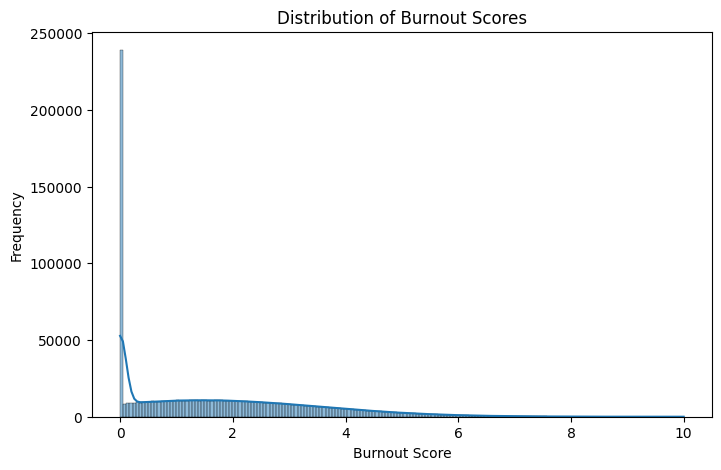

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['burnout_score'].dropna(), kde=True)
plt.title('Distribution of Burnout Scores')
plt.xlabel('Burnout Score')
plt.ylabel('Frequency')
plt.show()



### Observation
The burnout scores appear to follow a moderately distributed pattern, indicating varying stress levels among students.


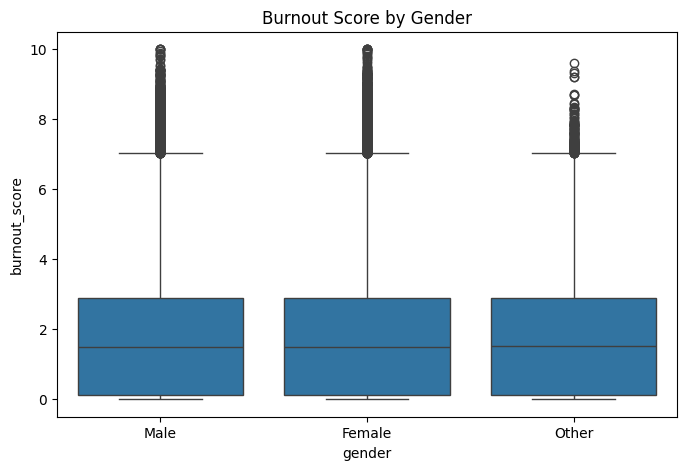

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='burnout_score', data=df)
plt.title('Burnout Score by Gender')
plt.show()


### Observation
The visualization helps compare burnout patterns across genders and identify any noticeable differences in stress levels.


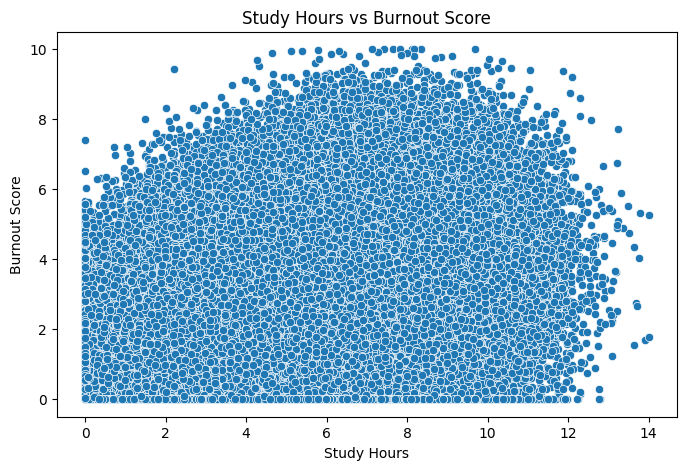

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='study_hours_per_day', y='burnout_score', data=df)
plt.title('Study Hours vs Burnout Score')
plt.xlabel('Study Hours')
plt.ylabel('Burnout Score')
plt.show()


### Observation
Students with higher study hours tend to show increased burnout trends, suggesting a possible relationship between workload and mental fatigue.


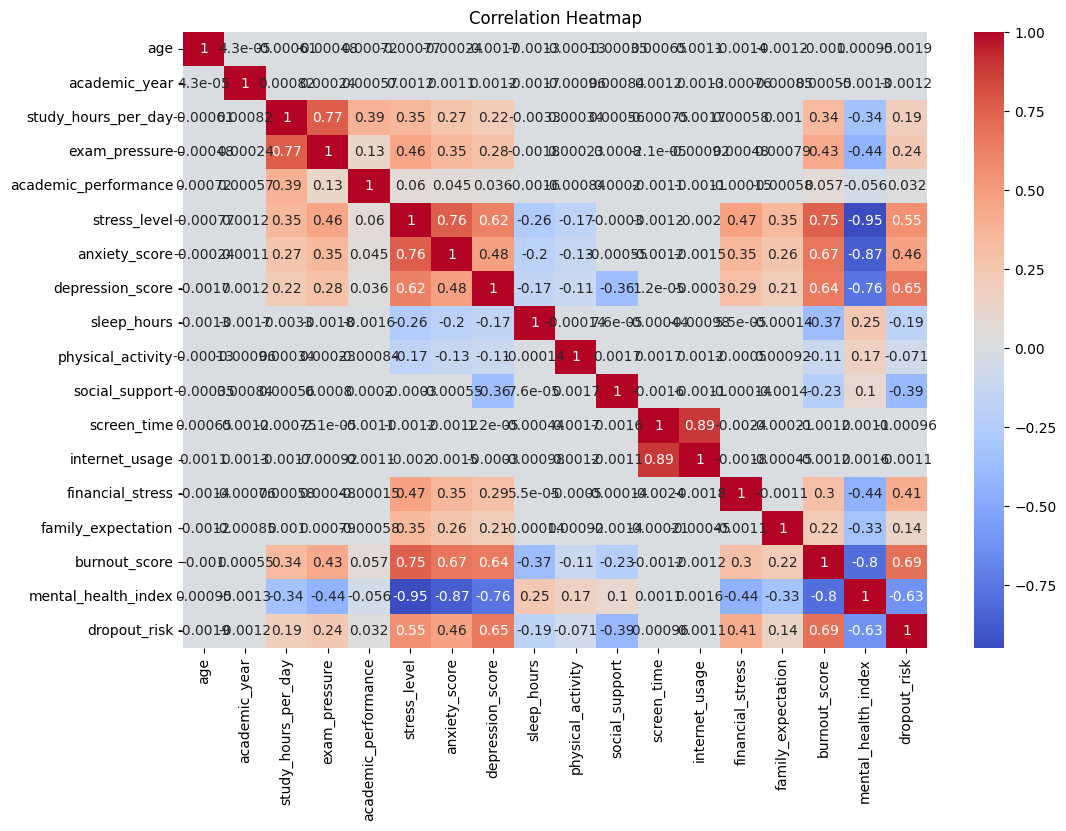

In [42]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Observation

The correlation heatmap shows that factors like stress level, exam_pressure , and dropout_risk have a positive correlation with burnout_score, meaning they tend to increase burnout. Conversely, burnout_score and sleep_hours have a negative correlation, suggesting they help reduce burnout. This gives us a quick overview of the most influential factors.


## Data Preprocessing

Data preprocessing is performed to improve data quality and prepare the dataset for machine learning. This includes handling missing values, encoding categorical features, and scaling numerical variables.


In [43]:
# Handle missing values
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

df.isnull().sum()

,0
age,0
gender,0
academic_year,0
study_hours_per_day,0
exam_pressure,0
academic_performance,0
stress_level,0
anxiety_score,0
depression_score,0
sleep_hours,0



## Feature Encoding & Scaling


In [44]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,1,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,1,1.746601
1,20,1,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,1,0.000000
2,29,1,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,1,0.696941
3,27,1,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,0,5.380592
4,24,1,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,1,0.000000



## Train-Test Split


In [45]:
X = df.drop('burnout_score', axis=1)
y = df['burnout_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (800000, 19)
Testing Shape: (200000, 19)


In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Model Building


In [47]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)



## Model Evaluation


In [48]:
def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"--- {name} ---")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

evaluate_model("Linear Regression", y_test, linear_predictions)
print()


--- Linear Regression ---
MAE : 0.5988379350534464
MSE : 0.6155542761572501
RMSE: 0.7845726710491834
R2 Score: 0.7774977890413914




## Feature Importance Analysis


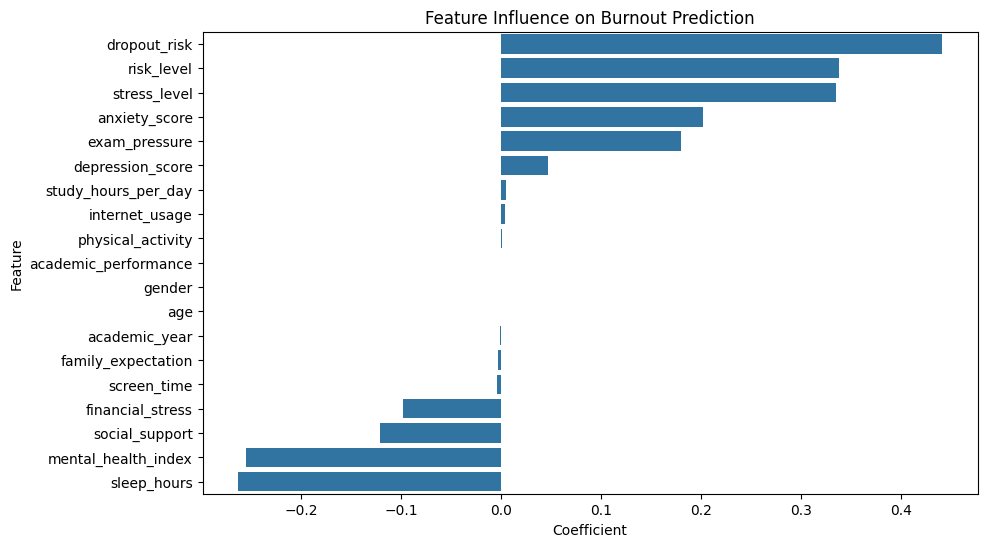

In [49]:
# Feature Influence Analysis

feature_analysis = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

feature_analysis = feature_analysis.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_analysis
)

plt.title('Feature Influence on Burnout Prediction')

plt.show()

### Observation

The coefficient analysis shows how different features influence student burnout prediction. Features with higher positive coefficient values contribute more strongly toward increasing burnout scores, while negative coefficients indicate an inverse relationship with burnout levels.

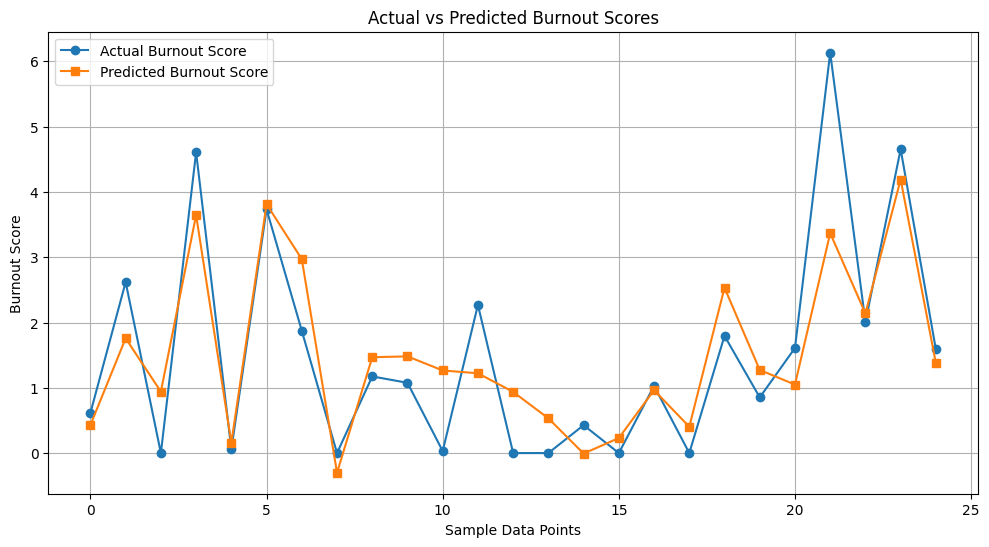

In [50]:
# Actual vs Predicted Burnout Score Visualization

comparison_df = pd.DataFrame({
    'Actual Burnout Score': y_test.values,
    'Predicted Burnout Score': linear_predictions
})

# Selecting first 25 samples for better visualization
comparison_sample = comparison_df.head(25)

plt.figure(figsize=(12,6))

plt.plot(
    comparison_sample['Actual Burnout Score'].values,
    marker='o',
    label='Actual Burnout Score'
)

plt.plot(
    comparison_sample['Predicted Burnout Score'].values,
    marker='s',
    label='Predicted Burnout Score'
)

plt.title('Actual vs Predicted Burnout Scores')
plt.xlabel('Sample Data Points')
plt.ylabel('Burnout Score')

plt.legend()
plt.grid(True)

plt.show()

# Actual vs Predicted Analysis


The predicted burnout scores follow a trend similar to the actual burnout scores for most of the sample data points. This indicates that the Linear Regression model is able to identify meaningful relationships between student-related factors and burnout levels.

Although some differences between actual and predicted values are observed, the model demonstrates reasonable predictive performance and provides a useful baseline for burnout prediction analysis.


## Conclusion



This project focused on predicting student mental health burnout levels using machine learning techniques. Various stages of the machine learning pipeline, including data preprocessing, exploratory data analysis, feature encoding, feature scaling, model training, and evaluation, were successfully implemented.

Linear Regression was used as the predictive model to analyze the relationship between academic, behavioral, and mental health-related factors affecting student burnout. The model was able to capture meaningful trends within the dataset and generate reasonably accurate burnout predictions.

The project demonstrates how machine learning can be applied to analyze student well-being and highlights the potential of AI-driven systems in supporting early burnout identification and mental health awareness.

